# Subtask 3 Model-Prompt Heatmap
This notebook visualizes the scores for each prompt on each model in Subtask 3 using a heatmap.

In [1]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Define the results directory
RESULTS_DIR = Path('../results/test')

In [3]:
# Load all result files and extract scores
def load_scores(results_dir):
    data = []
    for file_path in results_dir.glob('*.json'):
        try:
            with open(file_path, 'r') as f:
                metrics = json.load(f)
            filename = file_path.stem
            # Always parse model and prompt_id from filename
            if '_prompt_' in filename:
                model_name, prompt_part = filename.rsplit('_prompt_', 1)
                prompt_id = prompt_part
            else:
                model_name = filename
                prompt_id = 'unknown'
            # Add these fields regardless of JSON content
            metrics['model'] = model_name
            metrics['prompt_id'] = prompt_id
            data.append(metrics)
        except Exception as e:
            print(f'Error reading {file_path}: {e}')
    return pd.DataFrame(data)

In [4]:
# Load the scores
df = load_scores(RESULTS_DIR)

# Check columns and debug if needed
print(df.columns)  # Optional: see what columns are present

Index(['bleu', 'rouge1', 'rouge2', 'rougeL', 'rougeLsum', 'sari', 'bertscore',
       'medcon', 'alignscore', 'overall_score', 'model', 'prompt_id'],
      dtype='object')


In [5]:
df = load_scores(RESULTS_DIR)
print(df.head())         # Show first few rows
print(df.columns)        # Show all columns
print(len(df))           # Show number of rows

        bleu     rouge1     rouge2     rougeL  rougeLsum       sari  \
0   4.027650  28.102172   9.440192  19.766280  19.766280  54.292978   
1  11.441736  43.554597  18.998442  29.312527  29.312527  60.357567   
2   7.846986  40.894052  15.472645  26.767355  26.767355  56.989160   
3   5.946373  37.307011  12.902799  23.470654  23.470654  58.219059   
4   4.753149  29.449428   9.433716  19.792187  19.792187  54.659500   

   bertscore     medcon  alignscore  overall_score                    model  \
0  31.489404  24.067865   28.331269      26.995908  Echelon-AI-Med-Qwen2-7B   
1  46.133274  46.593320   38.260410      38.683139  google-gemini-2-5-flash   
2  42.470949  40.120688   30.448806      34.107324    google-medgemma-4b-it   
3  41.309150  43.673704   32.410120      34.171510   deepseek-deepseek-v3-2   
4  29.243528  27.726747   24.567332      26.790407  Echelon-AI-Med-Qwen2-7B   

  prompt_id  
0         8  
1         2  
2         2  
3         1  
4        10  
Index(['bleu',

In [6]:
# Ensure prompt_id is numeric and drop rows where it's missing
df['prompt_id'] = pd.to_numeric(df['prompt_id'], errors='coerce')
df = df.dropna(subset=['prompt_id'])
df['prompt_id'] = df['prompt_id'].astype(int)

In [7]:
# Add average column to the right and sort models within each section by average score
heatmap_df['Average'] = heatmap_df.mean(axis=1)

# Define model sections (closed first, then open)
closed_source_models = [
    'anthropic-claude-sonnet-4-5',
    'anthropic-claude-opus-4-6',
    'deepseek-deepseek-v3-2',
    'x-ai-grok-4-1-fast',
    'openai-gpt-5-mini',
    'qwen-qwen3-max-thinking',
    'google-gemini-3-flash-preview',
    'google-gemini-2-5-flash',
    'openai-gpt-4-1',
    'z-ai-glm-4-6v',
    # Add any others if needed
    # (keep in sync with your actual model list)
]
open_source_models = [
    'meta-llama-Llama-3-1-8B-Instruct',
    'google-medgemma-27b-text-it',
    'google-gemma-3-27b-it',
    'Qwen-Qwen3-32B',
    'Qwen-Qwen3-8B',
    'nvidia-NVIDIA-Nemotron-3-Nano-30B-A3B-FP8',
    'google-medgemma-4b-it',
    'Echelon-AI-Med-Qwen2-7B',
    'google-medgemma-1-5-4b-it',
    # Add any others if needed
    # (keep in sync with your actual model list)
]

# Sort each section by average score (descending)
closed_sorted = sorted(closed_source_models, key=lambda m: heatmap_df.loc[m, 'Average'] if m in heatmap_df.index else -float('inf'), reverse=True)
open_sorted = sorted(open_source_models, key=lambda m: heatmap_df.loc[m, 'Average'] if m in heatmap_df.index else -float('inf'), reverse=True)

# Combine for final order: closed first, then open
all_models = closed_sorted + open_sorted
heatmap_df = heatmap_df.reindex(all_models)

NameError: name 'heatmap_df' is not defined

In [8]:
# Plot the heatmap with open/closed source separation
open_source_models = [
    'meta-llama-Llama-3-1-8B-Instruct',
    'google-medgemma-27b-text-it',
    'google-gemma-3-27b-it',
    'Qwen-Qwen3-32B',
    'Qwen-Qwen3-8B',
    'nvidia-NVIDIA-Nemotron-3-Nano-30B-A3B-FP8',
    'google-medgemma-4b-it',
    'Echelon-AI-Med-Qwen2-7B',
    'google-medgemma-1-5-4b-it'
]
closed_source_models = [
    'anthropic-claude-sonnet-4-5',
    'deepseek-deepseek-v3-2',
    'x-ai-grok-4-1-fast',
    'openai-gpt-5-mini',
    'qwen-qwen3-max-thinking',
    'google-gemini-3-flash-preview',
    'google-gemini-2-5-flash',
    'openai-gpt-4-1',
]

# Sort each section alphabetically
open_source_models = sorted(open_source_models)
closed_source_models = sorted(closed_source_models)

# Combine and filter models to match DataFrame
all_models = open_source_models + closed_source_models
heatmap_df = heatmap_df.reindex(all_models)


NameError: name 'heatmap_df' is not defined

In [9]:
print(df['model'].unique())

['Echelon-AI-Med-Qwen2-7B' 'google-gemini-2-5-flash'
 'google-medgemma-4b-it' 'deepseek-deepseek-v3-2'
 'BioMistral-BioMistral-7B' 'Qwen-Qwen3-32B' 'openai-gpt-5-mini'
 'qwen-qwen3-max-thinking' 'anthropic-claude-opus-4-6'
 'google-medgemma-1-5-4b-it' 'meta-llama-Llama-3-1-8B-Instruct'
 'google-medgemma-27b-text-it' 'khazarai-Bio-8B-it' 'Qwen-Qwen3-8B'
 'google-gemma-3-27b-it' 'anthropic-claude-sonnet-4-5' 'openai-gpt-5-2'
 'x-ai-grok-4-1-fast' 'z-ai-glm-4-6v' 'openai-gpt-4-1'
 'google-gemini-3-flash-preview']


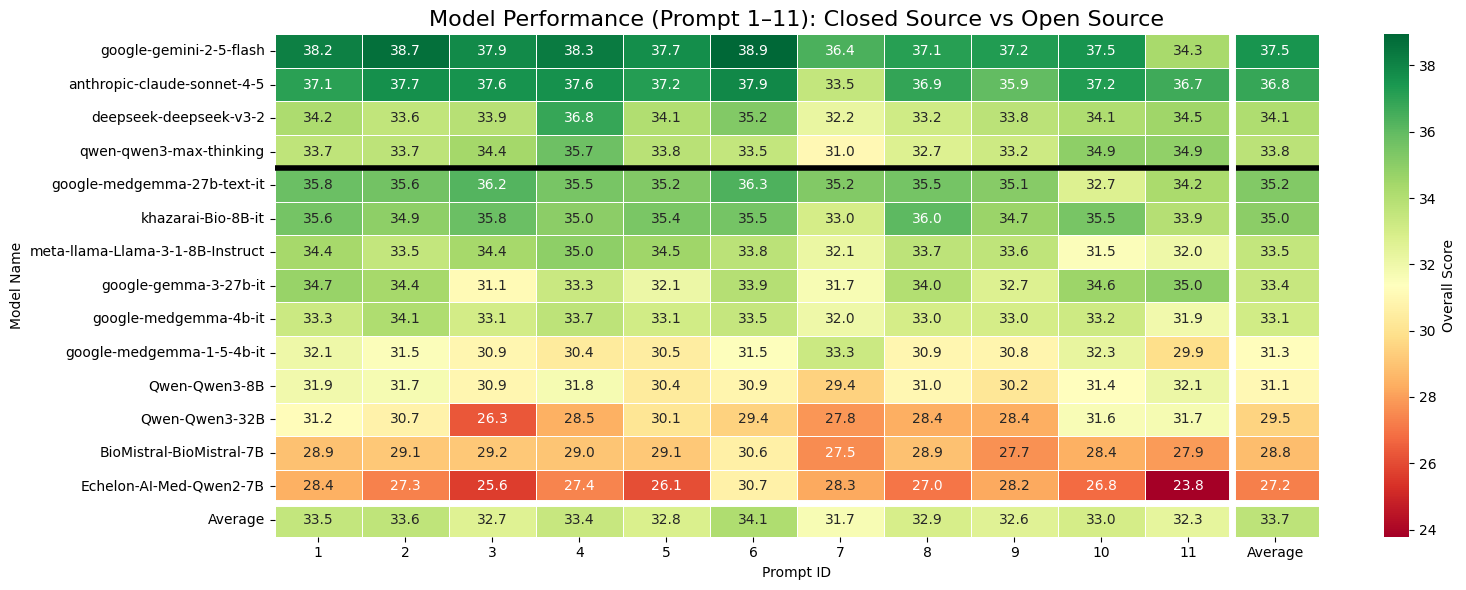

In [17]:
# --- Define Open Source and Closed Source Model Groups ---
open_source_models = [
    'meta-llama-Llama-3-1-8B-Instruct',
    'google-medgemma-27b-text-it',
    'google-gemma-3-27b-it',
    'Qwen-Qwen3-32B',
    'Qwen-Qwen3-8B',
    'Echelon-AI-Med-Qwen2-7B',
    'google-medgemma-4b-it',
    'google-medgemma-1-5-4b-it',
    'BioMistral-BioMistral-7B',
    'khazarai-Bio-8B-it'
# (normalize names to match your result files if needed)
 ]
closed_source_models = [
    'anthropic-claude-sonnet-4-5',
    'deepseek-deepseek-v3-2',
    'qwen-qwen3-max-thinking',
    'google-gemini-2-5-flash'
# (normalize names to match your result files if needed)
 ]

# --- Create Pivot Table ---
pivot_df = df.pivot_table(index="model", columns="prompt_id", values="overall_score")

# --- Add Average Columns/Rows ---
pivot_df['Average'] = pivot_df.mean(axis=1)
pivot_df.loc['Average'] = pivot_df.mean(axis=0)

# --- Sort by average within each section ---
def get_avg(model):
    try: return pivot_df.loc[model, 'Average']
    except: return -float('inf')

closed_sorted = sorted([m for m in closed_source_models if m in pivot_df.index], key=get_avg, reverse=True)
open_sorted = sorted([m for m in open_source_models if m in pivot_df.index], key=get_avg, reverse=True)

# --- Combine for final order: closed first, then open, then 'Average' row at the end ---
all_models = closed_sorted + open_sorted + ['Average']
pivot_df = pivot_df.reindex(all_models)

# --- Plot ---
plt.figure(figsize=(16, 6))
ax = sns.heatmap(
    pivot_df, 
    annot=True, 
    fmt=".1f",
    cmap="RdYlGn", 
    linewidths=0.5,
    cbar_kws={'label': 'Overall Score'}
)
ax = plt.gca()
sep_idx = len(closed_sorted)
# Draw thick line to separate closed and open source models (horizontal)
ax.axhline(y=sep_idx, color='black', linewidth=4)
# Draw thick line to separate prompts and average (vertical)
ax.axvline(x=pivot_df.shape[1]-1, color='white', linewidth=5)
# Optionally, make the bottom and right border lines thicker for clarity
ax.axhline(y=pivot_df.shape[0]-1, color='white', linewidth=5)
plt.title("Model Performance (Prompt 1–11): Closed Source vs Open Source", fontsize=16)
plt.ylabel("Model Name")
plt.xlabel("Prompt ID")
plt.tight_layout()
plt.savefig('subtask3_heatmap.png', dpi=300)
plt.show()
